In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from common import plotting
from common.assimilation import evaluate_prediction, run_abc, run_ode_model, run_pde_model, run_variational
from common.config import (
    ASSIM_BUDGETS,
    INITIAL_GUESS_ODE,
    INITIAL_GUESS_PDE,
    PARAM_BOUNDS_ODE,
    PARAM_BOUNDS_PDE,
    Params,
    results_dir,
)

OUT = results_dir("zad5")

np.random.seed(42)

TRUE_PARAMS = Params(D=0.1, p=0.01, q=1.0)
DEFAULTS = {"D": TRUE_PARAMS.D, "p": TRUE_PARAMS.p, "q": TRUE_PARAMS.q}
T_END = 5.0
DT = 1e-3
NX = 50
NOISE_STD = 0.05

ode_model = partial(run_ode_model, nx=NX, defaults=DEFAULTS)
pde_model = partial(run_pde_model, nx=NX, dt=DT, defaults=DEFAULTS)


Generating ground-truth data (PDE)...
Data generated. Assimilation window: t=[1.0, 3.0], samples: 40


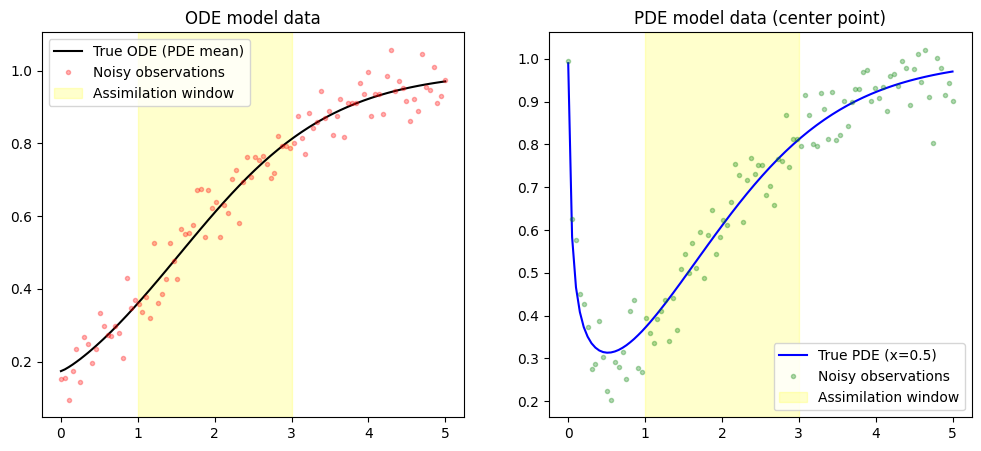

In [2]:
t_full = np.linspace(0, T_END, 100)
print("Generating ground-truth data (PDE)...")
u_true_pde = pde_model(DEFAULTS, t_full)
u_true_ode = np.mean(u_true_pde, axis=1).reshape(-1, 1)

obs_pde = u_true_pde + np.random.normal(0, NOISE_STD, u_true_pde.shape)
obs_ode = u_true_ode + np.random.normal(0, NOISE_STD, u_true_ode.shape)

t_start_assim, t_end_assim = 1.0, 3.0
mask_assim = (t_full >= t_start_assim) & (t_full <= t_end_assim)
t_assim = t_full[mask_assim]
obs_pde_assim, obs_ode_assim = obs_pde[mask_assim], obs_ode[mask_assim]

print(f"Data generated. Assimilation window: t=[{t_start_assim}, {t_end_assim}], samples: {len(t_assim)}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_full, u_true_ode, "k-", label="True ODE (PDE mean)")
plt.plot(t_full, obs_ode, "r.", alpha=0.3, label="Noisy observations")
plt.axvspan(t_start_assim, t_end_assim, color="yellow", alpha=0.2, label="Assimilation window")
plt.title("ODE model data")
plt.legend()

plt.subplot(1, 2, 2)
mid_idx = NX // 2
plt.plot(t_full, u_true_pde[:, mid_idx], "b-", label=f"True PDE (x={mid_idx / NX})")
plt.plot(t_full, obs_pde[:, mid_idx], "g.", alpha=0.3, label="Noisy observations")
plt.axvspan(t_start_assim, t_end_assim, color="yellow", alpha=0.2, label="Assimilation window")
plt.title("PDE model data (center point)")
plt.legend()
plt.show()


In [3]:
results_ode = {}
print("--- Experiment 1: ODE model ---")
for name, budget in ASSIM_BUDGETS.items():
    print(f"Budget: {name} ({budget}s)")
    print("  Running ABC...")
    params_abc, err_abc = run_abc(ode_model, obs_ode_assim, t_assim, PARAM_BOUNDS_ODE, budget)
    print(f"  ABC Result: {params_abc}, Error: {err_abc:.6f}")
    print("  Running Variational...")
    params_var, err_var = run_variational(ode_model, obs_ode_assim, t_assim, PARAM_BOUNDS_ODE, budget, INITIAL_GUESS_ODE)
    print(f"  Var Result: {params_var}, Error: {err_var:.6f}")
    results_ode[name] = {"ABC": {"params": params_abc, "error": err_abc}, "Var": {"params": params_var, "error": err_var}}


--- Experiment 1: ODE model ---
Budget: Low (2s)
  Running ABC...
  ABC Result: {'p': 0.0497855885518085, 'q': 0.8822324703012683}, Error: 0.002873
  Running Variational...
Variational finished. Time: 0.01s, Best MSE: 0.002871
  Var Result: {'p': np.float64(0.016558998413341075), 'q': np.float64(0.9656140208163105)}, Error: 0.002871
Budget: Medium (5s)
  Running ABC...
  ABC Result: {'p': 0.0520302882231288, 'q': 0.8712187533280755}, Error: 0.002873
  Running Variational...
Variational finished. Time: 0.01s, Best MSE: 0.002871
  Var Result: {'p': np.float64(0.016558998413341075), 'q': np.float64(0.9656140208163105)}, Error: 0.002871
Budget: High (15s)
  Running ABC...
  ABC Result: {'p': 0.05127847306061972, 'q': 0.8704774735594792}, Error: 0.002871
  Running Variational...
Variational finished. Time: 0.01s, Best MSE: 0.002871
  Var Result: {'p': np.float64(0.016558998413341075), 'q': np.float64(0.9656140208163105)}, Error: 0.002871


In [4]:
results_pde = {}
print("--- Experiment 2: PDE model ---")
for name, budget in ASSIM_BUDGETS.items():
    print(f"Budget: {name} ({budget}s)")
    print("  Running ABC...")
    params_abc, err_abc = run_abc(pde_model, obs_pde_assim, t_assim, PARAM_BOUNDS_PDE, budget)
    if params_abc:
        print(f"  ABC Result: {params_abc}, Error: {err_abc:.6f}")
    else:
        print("  ABC failed to find samples within the time budget.")
        params_abc, err_abc = INITIAL_GUESS_PDE, float("inf")
    print("  Running Variational...")
    params_var, err_var = run_variational(pde_model, obs_pde_assim, t_assim, PARAM_BOUNDS_PDE, budget, INITIAL_GUESS_PDE)
    print(f"  Var Result: {params_var}, Error: {err_var:.6f}")
    results_pde[name] = {"ABC": {"params": params_abc, "error": err_abc}, "Var": {"params": params_var, "error": err_var}}


--- Experiment 2: PDE model ---
Budget: Low (2s)
  Running ABC...
  ABC Result: {'D': 0.2914443988579936, 'p': 0.04024640792570967, 'q': 0.9243638106651058}, Error: 0.002703
  Running Variational...
Variational finished. Time: 2.01s, Best MSE: 0.002456
  Var Result: {'D': np.float64(0.10359900048494383), 'p': np.float64(0.0069474517687076595), 'q': np.float64(1.0116059684983603)}, Error: 0.002456
Budget: Medium (5s)
  Running ABC...
  ABC Result: {'D': 0.3040787255190723, 'p': 0.05491488179329605, 'q': 0.8904033379300735}, Error: 0.002476
  Running Variational...
Variational finished. Time: 3.09s, Best MSE: 0.002451
  Var Result: {'D': np.float64(0.09501991403255017), 'p': np.float64(0.02092953192453931), 'q': np.float64(0.9711611600572246)}, Error: 0.002451
Budget: High (15s)
  Running ABC...
  ABC Result: {'D': 0.2952577714582382, 'p': 0.04922273216992942, 'q': 0.9028335225466934}, Error: 0.002468
  Running Variational...
Variational finished. Time: 3.00s, Best MSE: 0.002451
  Var Re

--- ODE results (Budget: High) ---


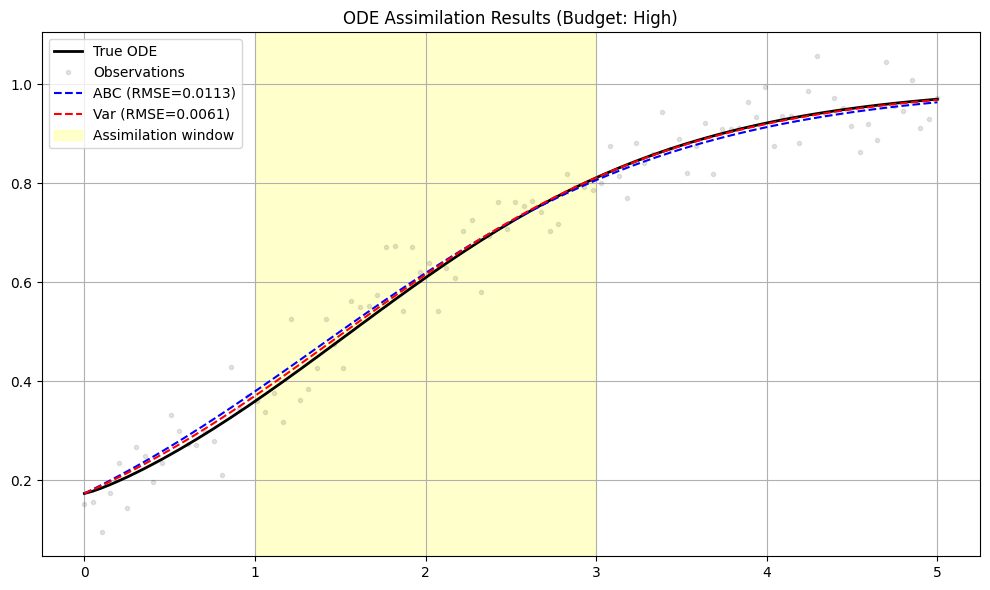

--- PDE results (Budget: High) ---


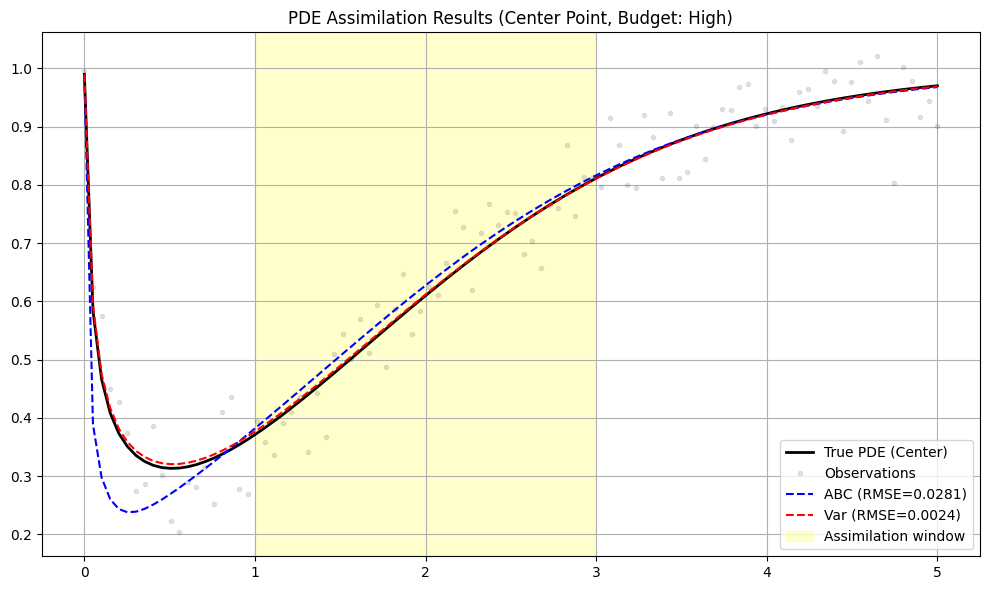

--- RMSE summary (total) ---
Model | Method | Low        | Medium     | High      
--------------------------------------------------
ODE   | ABC   | 0.011833   | 0.011640   | 0.011330   | 
ODE   | Var   | 0.006112   | 0.006112   | 0.006112   | 
PDE   | ABC   | 0.027117   | 0.029069   | 0.028052   | 
PDE   | Var   | 0.001675   | 0.002437   | 0.002437   | 


In [5]:
best_budget = "High"
assim_range = [t_start_assim, t_end_assim]

print(f"--- ODE results (Budget: {best_budget}) ---")
pred_ode_abc, rmse_ode_abc, _, _ = evaluate_prediction(
    ode_model, results_ode[best_budget]["ABC"]["params"], t_full, u_true_ode, assim_range)
pred_ode_var, rmse_ode_var, _, _ = evaluate_prediction(
    ode_model, results_ode[best_budget]["Var"]["params"], t_full, u_true_ode, assim_range)

plt.figure(figsize=(10, 6))
plt.plot(t_full, u_true_ode, "k-", linewidth=2, label="True ODE")
plt.plot(t_full, obs_ode, "k.", alpha=0.1, label="Observations")
plt.plot(t_full, pred_ode_abc, "b--", label=f"ABC (RMSE={rmse_ode_abc:.4f})")
plt.plot(t_full, pred_ode_var, "r--", label=f"Var (RMSE={rmse_ode_var:.4f})")
plt.axvspan(t_start_assim, t_end_assim, color="yellow", alpha=0.2, label="Assimilation window")
plt.title(f"ODE Assimilation Results (Budget: {best_budget})")
plt.legend()
plt.grid(True)
plotting.savefig(OUT / "ode_assimilation_results_budget_high.png", dpi=150)
plt.show()

print(f"--- PDE results (Budget: {best_budget}) ---")
pred_pde_abc, rmse_pde_abc, _, _ = evaluate_prediction(
    pde_model, results_pde[best_budget]["ABC"]["params"], t_full, u_true_pde, assim_range)
pred_pde_var, rmse_pde_var, _, _ = evaluate_prediction(
    pde_model, results_pde[best_budget]["Var"]["params"], t_full, u_true_pde, assim_range)

plt.figure(figsize=(10, 6))
plt.plot(t_full, u_true_pde[:, mid_idx], "k-", linewidth=2, label="True PDE (Center)")
plt.plot(t_full, obs_pde[:, mid_idx], "k.", alpha=0.1, label="Observations")
plt.plot(t_full, pred_pde_abc[:, mid_idx], "b--", label=f"ABC (RMSE={rmse_pde_abc:.4f})")
plt.plot(t_full, pred_pde_var[:, mid_idx], "r--", label=f"Var (RMSE={rmse_pde_var:.4f})")
plt.axvspan(t_start_assim, t_end_assim, color="yellow", alpha=0.2, label="Assimilation window")
plt.title(f"PDE Assimilation Results (Center Point, Budget: {best_budget})")
plt.legend()
plt.grid(True)
plotting.savefig(OUT / "pde_assimilation_results_center_budget_high.png", dpi=150)
plt.show()

print("--- RMSE summary (total) ---")
print(f"{'Model':<5} | {'Method':<5} | {'Low':<10} | {'Medium':<10} | {'High':<10}")
print("-" * 50)
for model_name, res_dict, model_func, u_true in [
    ("ODE", results_ode, ode_model, u_true_ode),
    ("PDE", results_pde, pde_model, u_true_pde),
]:
    for method in ["ABC", "Var"]:
        row = f"{model_name:<5} | {method:<5} | "
        for budget in ["Low", "Medium", "High"]:
            params = res_dict[budget][method]["params"]
            if params is None:
                row += f"{'N/A':<10} | "
            else:
                _, rmse, _, _ = evaluate_prediction(model_func, params, t_full, u_true, assim_range)
                row += f"{rmse:.6f}   | "
        print(row)
